In [5]:
# Import necessary libraries
import xarray as xr               # For reading and manipulating NetCDF data
import matplotlib.pyplot as plt   # For plotting
import cartopy.crs as ccrs        # For map projections
import cmocean                    # For scientific colormaps
import numpy as np                # For handling time strings
import os                         # To help with file paths (good practice)

In [6]:
# Set a default font size for better readability
plt.rcParams.update({'font.size': 12})

# Define the path to the NetCDF file on the server
file_path = ('/N/project/easg690_fall2025/data/ERA5/ds633.0/e5.oper.an.sfc/'
             '202106/e5.oper.an.sfc.128_136_tcw.ll025sc.2021060100_2021063023.nc')

# Open the dataset using xarray's open_dataset function
# We specify engine="netcdf4" for best compatibility
ds = xr.open_dataset(file_path, engine="netcdf4")
    
    
# 1. Select the variable 'TCW' (Total Column Water)
tcw_data = ds['TCW']

# 2. Select a specific timestep using the .isel() method
# We will select the very first timestep in the file (index 0)
tcw_single_time = tcw_data.isel(time=0)

# 3. (Optional) Print the summary of our selected data slice
print("\n--- Data slice for plotting ---")
print(tcw_single_time)



--- Data slice for plotting ---
<xarray.DataArray 'TCW' (latitude: 721, longitude: 1440)> Size: 4MB
[1038240 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time       datetime64[ns] 8B 2021-06-01
Attributes: (12/14)
    long_name:                     Total column water
    short_name:                    tcw
    units:                         kg m**-2
    original_format:               WMO GRIB 1 with ECMWF local table
    ecmwf_local_table:             128
    ecmwf_parameter:               136
    ...                            ...
    grid_specification:            0.25 degree x 0.25 degree from 90N to 90S ...
    rda_dataset:                   ds633.0
    rda_dataset_url:               https:/rda.ucar.edu/datasets/ds633.0/
    rda_dataset_doi:               DOI: 10.5065/BH6N-5N20
    rda_dataset_group:             ERA5 atmospheric

sh: getfattr: command not found



Starting plot generation...


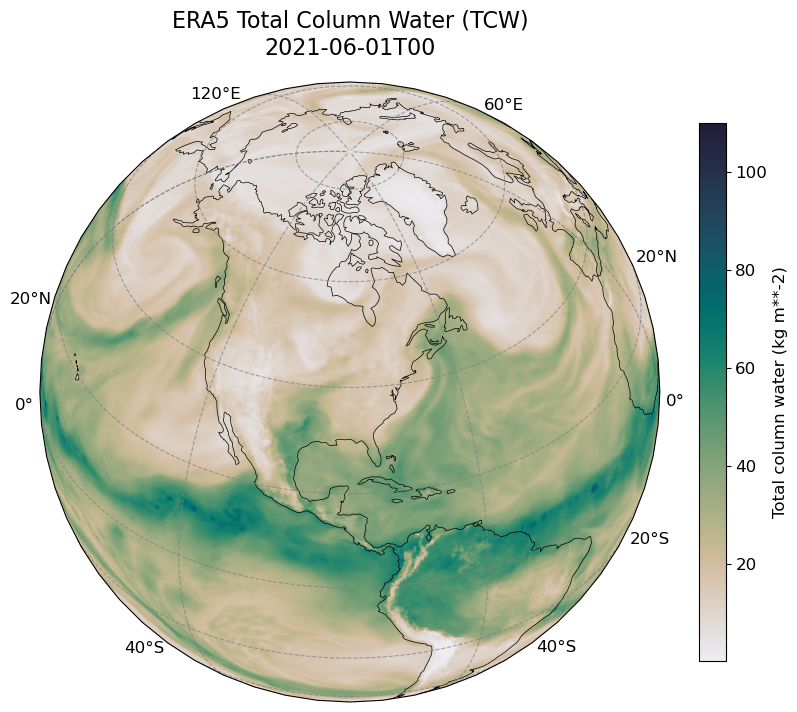

Plot generation complete.


In [12]:
# --- 1. Define Constants ---
# Coordinates for Bloomington, IN (latitude, longitude)
BLOOMINGTON_LAT = 39.1653
BLOOMINGTON_LON = -86.5264

# --- 2. Set up the Figure and Projection ---
print("\nStarting plot generation...")

# Create a matplotlib figure object. 
fig = plt.figure(figsize=(10, 10))

# Define the Cartopy map projection
projection = ccrs.Orthographic(central_longitude=BLOOMINGTON_LON,
                                central_latitude=BLOOMINGTON_LAT)

# Add an 'axes' to the figure with our chosen projection.
# The `projection` kwarg sets the *map's* projection.
ax = plt.axes(projection=projection)

# --- 3. Plot the Data ---
# Extract longitude and latitude coordinates from our xarray object
# These are needed for the plot axes.
lons = tcw_single_time['longitude']
lats = tcw_single_time['latitude']

# We use pcolormesh to create a 2D color plot of our gridded data.
#
# `transform=ccrs.PlateCarree()`: This is CRITICAL. It tells Cartopy that
# our source data (lons, lats) is in a standard latitude/longitude
# grid (PlateCarree) so it can be correctly re-projected onto our
# Orthographic map.
#
# `cmap=cmocean.cm.rain`: We use the 'rain' colormap from the cmocean
# library, which is perceptually uniform and good for water-related data.
plot = ax.pcolormesh(lons, lats, tcw_single_time,
                     transform=ccrs.PlateCarree(),
                     cmap=cmocean.cm.rain)

# --- 4. Add Map Features (Make it pretty) ---
# Add coastlines to the map
ax.coastlines(color='black', linewidth=0.5)

# Add gridlines (latitude and longitude lines)
# `draw_labels=True` adds lat/lon labels to the map edge (where possible)
# `linestyle='--'` makes the gridlines dashed
ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.7)

# Set the map to be global, showing the full globe
ax.set_global()

# --- 5. Add Colorbar and Title ---
# Add a colorbar to the plot
# `shrink=0.7` makes the colorbar 70% of the height of the axes
# `pad=0.05` adds a little space between the map and the colorbar
cbar = plt.colorbar(plot, ax=ax, orientation='vertical', shrink=0.7, pad=0.05)

# We can automatically get the label text from the data's attributes
cbar_label = f"{tcw_single_time.long_name} ({tcw_single_time.units})"
cbar.set_label(cbar_label, fontsize=12)

# Create a dynamic title using the time from the data
# np.datetime_as_string gives us a clean date/time string
time_str = np.datetime_as_string(tcw_single_time.time.values, unit='h')
ax.set_title(f"ERA5 Total Column Water (TCW)\n{time_str}", fontsize=16, pad=20)

# Display the plot in the notebook
plt.show()

print("Plot generation complete.")

In [ ]:
def generate_frame(i, input_file, output_dir):
    """
    Generates and saves a plot for a specific timestep from a NetCDF file.
    
    Args:
        i (int): The timestep index to plot.
        input_file (str): The path to the input NetCDF file.
        output_dir (str): The directory to save the image to.
    """
    
    # -----------------------------------------------------------------
    # Setup
    # -----------------------------------------------------------------
    
    # 1. Prevent figures from displaying in the notebook
    plt.ioff()
    
    # 2. Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # -----------------------------------------------------------------
    # Data Loading (copied and adapted from your notebook)
    # -----------------------------------------------------------------
    
    # Open the dataset
    with xr.open_dataset(input_file) as ds:
        # Select the 'TCW' variable and the single timestep 'i'
        tcw = ds['TCW'].isel(time=i)
        
        # Extract longitude and latitude coordinates
        # (This matches the code from your notebook snippet)
        lons = tcw['longitude']
        lats = tcw['latitude']
        
        # Get the time value for the plot title
        time_val = tcw['time'].values
        time_str = np.datetime_as_string(time_val, unit='s')

    # -----------------------------------------------------------------
    # Plotting (copied and adapted from your notebook)
    # -----------------------------------------------------------------
    
    # Find the Bloomington in IN.
    Bloomington_lat = 39.1653
    Bloomington_lon = -86.5264
    
    # use the Orthographic to plot the figure.
    fig = plt.figure(figsize=(10, 10))
    
    projection = ccrs.Orthographic(central_longitude=Bloomington_lon,
                                    central_latitude=Bloomington_lat)
    
    ax = plt.axes(projection=projection)
    
    # plot the data using pcolormesh method
    plot = ax.pcolormesh(lons, lats, tcw,
                         transform=ccrs.PlateCarree(),
                         cmap=cmocean.cm.rain)
    
    # --- Additions for a complete plot ---
    # Add coastlines and gridlines for context
    ax.coastlines()
    ax.gridlines()
    
    # Add a colorbar
    plt.colorbar(plot, ax=ax, orientation='vertical', label='Total Column Water (TCW)', shrink=0.8)
    
    # Add a title with the dynamic time
    ax.set_title(f'Total Column Water (TCW)\n{time_str}')
    
    # -----------------------------------------------------------------
    # Saving and Cleanup (as per hints)
    # -----------------------------------------------------------------
    
    # 1. Create a dynamic, zero-padded filename (e.g., frame_000.png, frame_001.png)
    filename = f"frame_{i:03d}.png"
    output_path = os.path.join(output_dir, filename)
    
    # 2. Save the figure
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    
    # 3. Close the figure to prevent memory issues
    plt.close(fig)

In [ ]:
# 1. Define the variables for your file path and output directory
# (This is the path you just provided)
input_file_path = ('/N/project/easg690_fall2025/data/ERA5/ds633.0/e5.oper.an.sfc/'
                   '202106/e5.oper.an.sfc.128_136_tcw.ll025sc.2021060100_2021063023.nc')

output_directory = 'frames_output'


# 2. Call the function to generate a few test frames
print(f"Generating frame for timestep 0...")
generate_frame(i=0, 
               input_file=input_file_path, 
               output_dir=output_directory)

print(f"Generating frame for timestep 10...")
generate_frame(i=10, 
               input_file=input_file_path, 
               output_dir=output_directory)

print("Test frames generated. Check the 'frames_output'")